# Разработка алгоритма жадного добавления

Для сравнительной оценки получаемых результатов с подходом описанным в СП 11.13130.2009

In [1]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx

# Загрузка исходных данных

Здесь используем данные для Сосновоборска, как тестовые.

In [ ]:
from fire_units.settings import DEFAULT_SPEEDS
from graphs.speeds import kmh_to_mm, set_graph_travel_times

# Загружаем данные
G = ox.load_graphml(r'tests\data\test_rng.ml')
print(G.number_of_nodes(), G.number_of_edges())

# # Создаем реверсный граф
# GR = nx.reverse(G, copy=True)

# Загрузка зданий
buildings = gpd.read_file(r'tests\data\buildings.gpkg')

# Устанавливаем скорости движения
set_graph_travel_times(G, speeds=DEFAULT_SPEEDS, morph_function=kmh_to_mm)


# Сопоставляем здания с узлами
# Узлы графа:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_gdf = ox.projection.project_gdf(nodes_gdf)
print('Узлов исходного ГДС:', len(nodes_gdf))

# Здания
print('Зданий:', len(buildings))
buildings = ox.projection.project_gdf(buildings, to_crs=nodes_gdf.crs)
buildings_centr = buildings.geometry.centroid
nearest_nodes = ox.nearest_nodes(ox.projection.project_graph(G), buildings_centr.x, buildings_centr.y, return_dist=True)
buildings['node'] = nearest_nodes[0]
buildings['node_distance'] = nearest_nodes[1]
buildings = buildings.query('node_distance <= 100')
buildings = ox.projection.project_gdf(buildings, to_latlong=True)
print('Зданий:', len(buildings))

fig, ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
buildings.plot(ax=ax)

# 1. Разработка алгоритма

## 1.2. Расчет матрицы достижимости от всех зданий

In [ ]:
buildings.head(5)

In [ ]:
from genesis.swiss_knife import MSF
from genesis.utils import Progressbar, TimeCheckPoint

time_bound = 9


df_size = len(buildings)
pb = Progressbar(df_size, bins=40)
t = TimeCheckPoint()

d = {}
for id, building in buildings.iterrows():
    node = building['node']
    length = nx.shortest_path_length(G, target = node, weight = 'travel_time')
    length = {k:v for k,v in length.items() if v <= time_bound}   
    d[id] = pd.Series(length).notna()
    pb()

matrix = pd.DataFrame(d).T
matrix.shape

print('Потребовалось времени:', t())

In [ ]:
matrix

In [ ]:
matrix.to_csv('greedy_adding_matrix.csv')

## 1.3. Алгоритм

1. Если матрица не равна нулю (имеется хоть одна строка или неприкрытое здание) увеличиваем количество мест размещения на 1.
Ищем максимальную сумму среди всех узлов - это тот у зел, размещение в котором обеспечит покрытие максимального количества зданий
2. Определяем его номер
3. Поэтому номеру получаем маску покрытых узлов
4. Из матрицы достижимости выбрасываем все узлы покрытые имеющимся размещением

5. Повторяем все предыдущие шаги до тех пор пока не закончится вся матрица

In [ ]:
# pd.set_option('future.no_silent_downcasting', True)

In [ ]:
matrix_temp = matrix.copy()
units = []
covered_buildings_count = 0

print(len(matrix_temp))
while len(matrix_temp) > 0:
    node_id = matrix_temp.columns[np.argmax(np.sum(matrix_temp, axis=0))]
    units.append(int(node_id))
    node_column = matrix_temp[node_id]

    covered_buildings_count += node_column.sum()
    print('Прикрыто зданий', node_column.sum(), 'и всего:', covered_buildings_count, 'узел:', node_id)
    # node_column = node_column.fillna(False)

    # # Определения количества прикрытых зданий
    # nodes_list = list(node_column[node_column].index)
    # covered_buildings_count += len(buildings.query(f'node in @nodes_list'))
    # print(len(buildings.query(f'node in @nodes_list')), covered_buildings_count)

    matrix_temp = matrix_temp[node_column.isna()]
    print(matrix_temp.shape, len(units), 100 * (1 - (len(matrix_temp) / len(matrix))), ' '*5)   #, end = '\r')
    # print(matrix_temp.shape, len(units), 100 * (covered_buildings_count / len(buildings)), ' '*5)    

In [ ]:
units

In [ ]:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)

fig,ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
nodes_gdf.loc[units].plot(ax=ax, color='red', edgecolor='black')


# 2. Сопоставление со временем расчета для инструментов **genesis**

Проверка для полученных жадным добавлением размещений

In [ ]:
from genesis.metrics import CoverIndex, ArrivalTime
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import ArrivalTimeBuilding, CoverIndexBuilding


time_bound = 10

dynamic_nodes = {}
i = 0
for n in units[:2]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

times, _ = FirstArrivalUnitState()(env = G, points = dynamic_nodes)
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings)(times))


nodes_gdf = ox.graph_to_gdfs(G, edges=False)
fig,ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
nodes_gdf.loc[dynamic_nodes.keys()].plot(ax=ax, color='red', edgecolor='black')

In [41]:
from genesis.metrics import CoverIndex, ArrivalTime
from genesis.states import FirstArrivalUnitState


def iter_func(**kwds):
    'Функция вывода хода расчета'
    i = kwds['i']
    best_metric = kwds['best_metric']
    print(f'Копт: шаг {i} лучшая метирка: {best_metric}')

# mclp_history = []
def mclp_end_function(iteration, best_metric, dynamic_nodes, static_nodes, **kwargs):
    units_count = len(dynamic_nodes) + len(static_nodes)
    mclp_history.append([units_count, best_metric])
    msg = f'Итерация: {iteration} | Подразделений {units_count} | Лучшая метрика: {best_metric}    '
    print(' ')
    print(msg)

    pd.DataFrame(mclp_history, columns=['iter', 'metric']).to_csv(history_name)


def epoch_end_function(epoch, best_metric, cur_metric, **kwargs):
    print(f'Эпоха: {epoch} |', f'Лучшая метрика: {best_metric}    ', end='\r')

def stop_case_function(target_ip=90,
                            ip_val=10):
    def stop_case_function_(value,
                            iteration,
                            best_metric,
                            current_metric,
                            dynamic_nodes,
                            static_nodes,
                            ):

        ip = value
        print(f'Текущий ИП-{ip_val}:', ip, target_ip)
        if ip >= target_ip:
            return True
        return False
    
    return stop_case_function_

def print_metrics(env, dynamic_nodes, existed_units_dict, ip_val=3):
    all_nodes = {**existed_units_dict, **dynamic_nodes}
    times, _ = FirstArrivalUnitState()(env = env, points = all_nodes)
    print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(all_nodes))
    print(f'ИП-{ip_val} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times))

In [ ]:
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean
from fire_units.metrics import ArrivalTimeBuilding
from fire_units.mclp import BestNodesGAKopt
from genesis.best_points import BestNodeBee
from genesis.mclp import BestNodesKoptG
from genesis.point_selectors import RandomNodesSelector
from genesis.stop_cases import NSameStopCase


time_bound = 10


dynamic_nodes = {}
i = 0
for n in units[:2]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

times, _ = FirstArrivalUnitState()(env = G, points = dynamic_nodes)
print('Исходно')
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings)(times))

metric_target = CoverIndexBuilding(buildings, ip_val = time_bound)
# metric_target = ArrivalTimeBuilding(buildings)

# Функция оптимизации k узлов методом hillclimber
bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState())
abc = BestNodeBee(state_function=FirstArrivalUnitState(),
                  metric_function=ArrivalTime(),
                  scouts_count=20,
                  best_scouts_count=4)


kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function = metric_target,
                       best_point_function=abc,
                       iterations=4,
                       iter_calc_end_function=iter_func,
                       )


gakopt = BestNodesGAKopt(state_function = FirstArrivalUnitState(),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),                    
                    population_size = 200,
                    epochs = 25,
                    elite_size = 25,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 10,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )



best_dynamic_nodes, best_metric = kopt(env = G,
                                dynamic_nodes = dynamic_nodes,
                                )

times, _ = FirstArrivalUnitState()(env = G, points = best_dynamic_nodes)
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), metric_target(times))

In [ ]:

from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean
from fire_units.mclp import BestNodesGAKopt
from fire_units.metrics import CoverIndexBuilding
from genesis.lscp import LSCPCommon, drop_trash_points
from genesis.mclp import BestNodesKoptG
from genesis.metrics import ArrivalTime
from genesis.point_selectors import GenesisNodeSelector, RandomNodesSelector
from genesis.states import FirstArrivalUnitState
from genesis.stop_cases import NSameStopCase


time_bound = 10
target_ip  = 99





# metric_opt = ArrivalTime()
metric_target = CoverIndexBuilding(buildings, ip_val = time_bound)

# Функция оптимизации k узлов методом hillclimber
bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState())

kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function = metric_target,
                       best_point_function=bnhc,
                       iterations=3,
                       iter_calc_end_function=iter_func,
                       )


gakopt = BestNodesGAKopt(state_function = FirstArrivalUnitState(),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),                    
                    population_size = 75,
                    epochs = 25,
                    elite_size = 15,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 5,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )


genesis = LSCPCommon(
                    mclp_function = gakopt,
                    # mclp_function = kopt,
                    point_selector = RandomNodesSelector(),
                    # point_selector = GenesisNodeSelector(FirstArrivalUnitState(delay=0), metric_target),
                    metric_function = metric_target,                        
                    # stop_case_function = MoreEqualStopCase(90),     # stop_case_function,
                    stop_case_function = stop_case_function(target_ip = target_ip, ip_val=time_bound),     # stop_case_function,
                    start_names_index = 3,
                    names_pattern='псч {}',
                    after_mclp_function = mclp_end_function,
                    )

dynamic_nodes = {
    list(nodes_gdf.index)[100]: 'псч 1',
    list(nodes_gdf.index)[200]: 'псч 2',
}

t()
# Собственно расчет
print('До LSCP:', len(dynamic_nodes))
best_dynamic_nodes, best_metric = genesis(env = G,
                                dynamic_nodes = dynamic_nodes,
                                # static_nodes = existed_units_dict,                          
                                # area = points_mask,
                                )
print('После LSCP:', len(best_dynamic_nodes), t())

optimal_nodes, best_metric = drop_trash_points(G,
                                FirstArrivalUnitState(),
                                metric_target,
                                stop_case_function(target_ip = target_ip),
                                best_dynamic_nodes,
                                # static_nodes = existed_units_dict,   
                                )
print('После отброса:', len(optimal_nodes), t())


times, _ = FirstArrivalUnitState()(env = G, points = optimal_nodes)
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings)(times))

# Тест времени расчета для графа Красноярска

In [4]:
from fire_units.settings import DEFAULT_SPEEDS
from graphs.speeds import kmh_to_mm, set_graph_travel_times

# G = ox.load_graphml(r'C:\QGIS\Красноярск Демо\______________ef3f7396_30d9_4d94_b617_55ad61b06e30.ml')
# G = ox.load_graphml(r'G:\QGIS\_Красноярск ДИССЕРТАЦИЯ\fire_data\rng.ml')
G = ox.load_graphml(r'D:\QGIS\_Красноярск ДИССЕРТАЦИЯ\fire_data\rng.ml')
print(G.number_of_nodes(), G.number_of_edges())

# Устанавливаем скорости движения
set_graph_travel_times(G, speeds=DEFAULT_SPEEDS, morph_function=kmh_to_mm)

31293 77344


d:\Git\genesis\work\genesis\graphs\speeds.py:98: UserWarning: Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. Рекомендуется устанавливать время следования для неупрощенного графа и только после этого упрощать
  warnings.warn("Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. " + \


In [5]:
# Загрузка зданий
# buildings = gpd.read_file(r'C:\QGIS\Красноярск Демо\data\bld.gpkg')
# buildings = gpd.read_file(r'G:\QGIS\_Красноярск ДИССЕРТАЦИЯ\data\bld.gpkg')
buildings = gpd.read_file(r'D:\QGIS\_Красноярск ДИССЕРТАЦИЯ\data\bld.gpkg')

# Сопоставляем здания с узлами
# Узлы графа:
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
nodes_gdf = ox.projection.project_gdf(nodes_gdf)

# Здания
print('Зданий:', len(buildings))
buildings = ox.projection.project_gdf(buildings, to_crs=nodes_gdf.crs)
buildings_centr = buildings.geometry.centroid
nearest_nodes = ox.nearest_nodes(ox.projection.project_graph(G), buildings_centr.x, buildings_centr.y, return_dist=True)
buildings['node'] = nearest_nodes[0]
buildings['node_distance'] = nearest_nodes[1]
buildings = buildings.query('node_distance <= 100')
buildings = ox.projection.project_gdf(buildings, to_latlong=True)
print('Зданий:', len(buildings))

Зданий: 58094
Зданий: 51317


#### Определение субсета данных о зданиях

In [6]:
df_size = int(len(buildings) * 0.2)
buildings_set = buildings.sample(df_size)
print(f'Расчет для {df_size} зданий')

Расчет для 10263 зданий


#### Расчет матрицы с использованием зданий в качестве цели

    nx.shortest_path_length

In [ ]:
# from genesis.utils import Progressbar, TimeCheckPoint

# time_bound = 9



# print(f'Расчет для {df_size} зданий')
# pb = Progressbar(df_size, bins=40)
# t = TimeCheckPoint()

# d = {}
# # for id, building in buildings.sample(df_size).iterrows():
# for id, building in buildings_set.iterrows():
#     node = building['node']
#     length = nx.shortest_path_length(G, target = node, weight = 'travel_time')
#     length = {k:v for k,v in length.items() if v <= time_bound}   
#     d[id] = pd.Series(length).notna()
#     pb()

# matrix = pd.DataFrame(d).T
# print('Размер матрицы:', matrix.shape)

# print('Потребовалось времени:', t())

In [ ]:
# matrix_temp = matrix.copy()
# units = []
# covered_buildings_count = 0

# print(len(matrix_temp))
# while len(matrix_temp) > 0:
#     node_id = matrix_temp.columns[np.argmax(np.sum(matrix_temp, axis=0))]
#     units.append(int(node_id))
#     node_column = matrix_temp[node_id]

#     # Определения количества прикрытых зданий
#     covered_buildings_count += node_column.sum()
#     print('Прикрыто зданий', node_column.sum(), 'и всего:', covered_buildings_count, 'узел:', node_id)

#     matrix_temp = matrix_temp[node_column.isna()]
#     print(matrix_temp.shape, len(units), 100 * (1 - (len(matrix_temp) / len(matrix))), ' '*5)   #, end = '\r') 

#### Расчет матрицы с использованием `cutoff` и реверсного графа

    nx.multi_source_dijkstra_path_length

In [7]:
from genesis.utils import Progressbar, TimeCheckPoint

GR = nx.reverse(G, copy=True)

time_bound = 9


print(f'Расчет для {df_size} зданий')
pb = Progressbar(df_size, bins=40)
t = TimeCheckPoint()

d = {}
for id, building in buildings_set.iterrows():
    node = building['node']
    length = nx.multi_source_dijkstra_path_length(GR, sources=[node], weight = 'travel_time', cutoff=time_bound)
    d[id] = pd.Series(length) 
    pb()

matrix = pd.DataFrame(d).T
print('Размер матрицы:', matrix.shape)

print('Потребовалось времени:', t())

Расчет для 10263 зданий
|########################################| 100.0%
Размер матрицы: (10263, 30950)
Потребовалось времени: 363.31


In [8]:
matrix_temp = matrix.copy().notna()
units = []
covered_buildings_count = 0

print(len(matrix_temp))
while len(matrix_temp) > 0:
    node_id = matrix_temp.columns[np.argmax(np.sum(matrix_temp, axis=0))]
    # node_id = matrix_temp.columns[np.argmax(matrix_temp.sum())]
    units.append(int(node_id))
    node_column = matrix_temp[node_id]

    # Определения количества прикрытых зданий
    covered_buildings_count += node_column.sum()
    print('Прикрыто зданий', node_column.sum(), 'и всего:', covered_buildings_count, 'узел:', node_id)

    matrix_temp = matrix_temp[node_column == False]
    print(matrix_temp.shape, len(units), 100 * (1 - (len(matrix_temp) / len(matrix))), ' '*5)   #, end = '\r') 

print('Итого ПСЧ требуется', len(units))

10263
Прикрыто зданий 2631 и всего: 2631 узел: 8089328360
(7632, 30950) 1 25.635779011984805      
Прикрыто зданий 2546 и всего: 5177 узел: 316563506
(5086, 30950) 2 50.44334015395109      
Прикрыто зданий 1442 и всего: 6619 узел: 750722041
(3644, 30950) 3 64.49381272532398      
Прикрыто зданий 981 и всего: 7600 узел: 1537263273
(2663, 30950) 4 74.05242131930234      
Прикрыто зданий 823 и всего: 8423 узел: 1306505164
(1840, 30950) 5 82.07151904901102      
Прикрыто зданий 340 и всего: 8763 узел: 1809972239
(1500, 30950) 6 85.38439052908507      
Прикрыто зданий 309 и всего: 9072 узел: 357878278
(1191, 30950) 7 88.39520608009353      
Прикрыто зданий 280 и всего: 9352 узел: 3023759754
(911, 30950) 8 91.12345318133099      
Прикрыто зданий 136 и всего: 9488 узел: 1060703001
(775, 30950) 9 92.44860177336062      
Прикрыто зданий 130 и всего: 9618 узел: 1514360570
(645, 30950) 10 93.71528792750658      
Прикрыто зданий 98 и всего: 9716 узел: 731246457
(547, 30950) 11 94.67017441293969   

#### Метрика оценки матрицы прикрытия

In [27]:
from genesis.core import MetricBase, StateBase


class CoverState(StateBase):
    def __init__(self,
                 matrix,
                 state_algorithm = np.any,
                 **kwargs):
        self.matrix = matrix
        self.state_algorithm = state_algorithm

    def __call__(self,
                 env    = None,
                 points = None,
                 area   = None,
                 **kwargs):
        '''
        `**kwargs`:
            Данные которые используются для расчета.
            
            Согласно правилам genesis, должны быть переданы следующие данные:
            
            `env` (`среда`): pd.DataFrame
                данные среды используемые для проведения расчетов.
                Граф, растр или иное представление пространства, в том числе композитное.

            `points`: list|dict (source)
                Стартовые точки. Может быть списком узлов вида list(int), или словарем вида dict(int:str), где ключ - 
                идентификатор узла, значение - его наименование. 
                Точки должны быть соотносимы с окружением `env`.

            `area` (`область оценки`): abstract = None
                область для которой происходит оценивание метрики.
                ни какие точки являющиеся частью среды `env`, но расположенные
                вне `area` учтены при оценке метрики не будут.

            Конкретный тип данных и их именование в аргументах осуществляются 
            непосредственно при реализации
        
        # Возвращает
        `state` : abstract
            Состояние среды. Зависит от конкретной реализации
        '''
        # print(points)
        if isinstance(points, dict):
            return self.state_algorithm(self.matrix[points.keys()], axis=1), None
        else:return self.state_algorithm(self.matrix[points], axis=1), None

        # return self.state_algorithm(self.matrix[points], axis=1), None


class CoverIndexBuildingByMatrix(MetricBase):

    def __init__(self, comp_func=max, **kwargs):
        '''
        `comp_func`: function
            Функция по которой происходит сравнение двух метрик методом compare.
            По умолчанию выбирается минимальная.

        `**kwargs`:
            Основные настройки объекта.

            В наиболее общем случае - функция np.mean,
            которая будет отвечать за расчет значения

            Пользователь может указать собственную функцию.
        '''
        self.comp_func=comp_func

    def __call__(self, state, area=None, **kwargs):
        '''
        `state` (`состояние`): abstract
            Абстрактный объект состояния среды.
            Например, словарь времен прибытия в разные точки.

        `area` (`область`): abstract
            Абстрактный объект конкретизирующий часть среды,
            состояние которой должно быть учтено при расчете метрики. 

        `**kwargs`:
            Прочие данные которые используются для вычислений.
            Например, частные настройки алгоритма, дополнительные данные и т.д.

        # Возвращает
        `metric` (`значение метрики`): float
            значение метрики
        '''
        return 100 * sum(state)/len(state)
    






state_func = CoverState(matrix.copy().notna())




In [28]:
dynamic_nodes = {}
i = 0
for n in units[:6]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

print(dynamic_nodes)

state, _ = state_func(points=dynamic_nodes)
CoverIndexBuildingByMatrix()(state)

{8089328360: 'pre 0', 316563506: 'pre 1', 750722041: 'pre 2', 1537263273: 'pre 3', 1306505164: 'pre 4', 1809972239: 'pre 5'}


85.38439052908507

In [42]:
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean, BestNodeHillClimbing_maxMean_Metric
from genesis.mclp import BestNodesGA
from genesis.point_selectors import RandomNodeInDistanceSelector
from genesis.stop_cases import MoreEqualStopCase
from genesis.point_selectors import GenesisNodeSelector, RandomNodesSelector, FarNodeSelector, RandomNodeInDistanceSelector


time_bound = 10
target_ip  = 99.75
DISTANCE   = 500



state_func = CoverState(matrix.copy().notna())
metric_target = CoverIndexBuildingByMatrix()
node_selector = RandomNodesSelector(nodes_list = set(matrix.columns))

# Функция оптимизации k узлов методом hillclimber
bnhc = BestNodeHillClimbing_maxMean_Metric(state_function  = state_func,
                                           metric_function = metric_target)


kopt = BestNodesKoptG(state_function          = state_func,
                       metric_function        = metric_target,
                       best_point_function    = bnhc,
                       iterations             = 5,
                       iter_calc_end_function = iter_func,
                       )


# gakopt = BestNodesGAKopt(state_function = state_func,
#                     metric_function = metric_target,
#                     kopt_function = kopt,
#                     node_selector = node_selector,                  
#                     population_size = 60,
#                     epochs = 20,
#                     elite_size = 15,
#                     epoch_end_function = epoch_end_function,
#                     mutation_max_count = 2,
#                     mutation_rate = 1,
#                     stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
#                     )

ga = BestNodesGA(state_function = state_func,
                    metric_function = metric_target,
                    node_selector = node_selector,
                    # node_selector = RandomNodeInDistanceSelector(g_nodes = ox.projection.project_gdf(nodes_gdf),
                    #                                              nodes_list = set(matrix.columns),
                    #                                              distance=DISTANCE),
                    population_size = 75,
                    epochs = 100,
                    # elite_size = 15,
                    epoch_end_function = epoch_end_function,
                    # mutation_max_count = 0.75,
                    # mutation_rate = 1,
                    stop_case_function = NSameStopCase(50)      # Условие остановки не менее N одинаковых метрик
                    )


lscp = LSCPCommon(
                    mclp_function = ga,
                    # mclp_function = kopt,
                    # point_selector = RandomNodesSelector(),
                    point_selector = node_selector,
                    # point_selector = FarNodeSelector(FirstArrivalUnitState(), nodes_list = set(matrix.columns)),   
                    # point_selector = RandomNodeInDistanceSelector(ox.projection.project_gdf(nodes_gdf), distance=DISTANCE),
                    # point_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),
                    metric_function = metric_target,
                    # stop_case_function = MoreEqualStopCase(90),     # stop_case_function,
                    # stop_case_function = stop_case_function(target_ip = target_ip, ip_val=time_bound),     # stop_case_function,
                    stop_case_function = MoreEqualStopCase(target_ip),     # stop_case_function,
                    start_names_index = 100,
                    names_pattern='псч {}',
                    after_mclp_function = mclp_end_function,
                    )

dynamic_nodes = {}
i = 0
for n in units[:10]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1
# g_nodes = list(G.nodes())
# dynamic_nodes[g_nodes[1000]] = '1'
# dynamic_nodes[g_nodes[2000]] = '2'
print(dynamic_nodes)

times, _ = FirstArrivalUnitState()(env = G, points = dynamic_nodes)
print('Исходно')
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings_set, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings_set)(times))



t = TimeCheckPoint()
# Собственно расчет
print('До LSCP:', len(dynamic_nodes))
# best_dynamic_nodes, best_metric = ga(env = G,
#                                 dynamic_nodes = dynamic_nodes,
#                                 )
best_dynamic_nodes, best_metric = lscp(env = G,
                                dynamic_nodes = dynamic_nodes,
                                )
print('После LSCP:', len(best_dynamic_nodes), t())

optimal_nodes, best_metric = drop_trash_points(G,
                                state_func,
                                metric_target,
                                stop_case_function(target_ip = target_ip),
                                best_dynamic_nodes,
                                # static_nodes = existed_units_dict,   
                                )
print('После отброса:', len(optimal_nodes), t())

{8089328360: 'pre 0', 316563506: 'pre 1', 750722041: 'pre 2', 1537263273: 'pre 3', 1306505164: 'pre 4', 1809972239: 'pre 5', 357878278: 'pre 6', 3023759754: 'pre 7', 1060703001: 'pre 8', 1514360570: 'pre 9'}
Исходно
Новых ПСЧ: 10 Всего ПСЧ: 47
ИП-10 =  93.82499268364062 %, tпр =  7.399051785978642 6.963829281436448
До LSCP: 10
 поха: 59 | Лучшая метрика: 94.13426873233948    
Итерация: 0 | Подразделений 10 | Лучшая метрика: 94.13426873233948    
 поха: 50 | Лучшая метрика: 94.89428042482704    
Итерация: 1 | Подразделений 11 | Лучшая метрика: 94.89428042482704    
 поха: 65 | Лучшая метрика: 95.58608593978369    
Итерация: 2 | Подразделений 12 | Лучшая метрика: 95.58608593978369    
 поха: 74 | Лучшая метрика: 96.04404170320569    
Итерация: 3 | Подразделений 13 | Лучшая метрика: 96.04404170320569    
 поха: 72 | Лучшая метрика: 96.73584721816233    
Итерация: 4 | Подразделений 14 | Лучшая метрика: 96.73584721816233    
 поха: 49 | Лучшая метрика: 97.04764688687519    
Итерация: 5 | По

# Расчет с использованием методов Genesis

In [12]:
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean, BestNodeHillClimbing_maxMean_Metric
from fire_units.mclp import BestNodesGAKopt
from fire_units.metrics import CoverIndexBuilding, ArrivalTimeBuilding
from genesis.lscp import LSCPCommon, drop_trash_points
from genesis.mclp import BestNodesKoptG
from genesis.metrics import ArrivalTime
from genesis.best_points import BestNodeHillClimbing
from genesis.point_selectors import GenesisNodeSelector, RandomNodesSelector, FarNodeSelector, RandomNodeInDistanceSelector
from genesis.states import FirstArrivalUnitState
from genesis.stop_cases import NSameStopCase
from genesis.utils import Progressbar, TimeCheckPoint

#### Оценка предложенного размещения

Исходно
Новых ПСЧ: 6 Всего ПСЧ: 47
ИП-10 =  85.48434299092771 %, tпр =  8.292271804338936 7.7894132399406555


<Axes: >

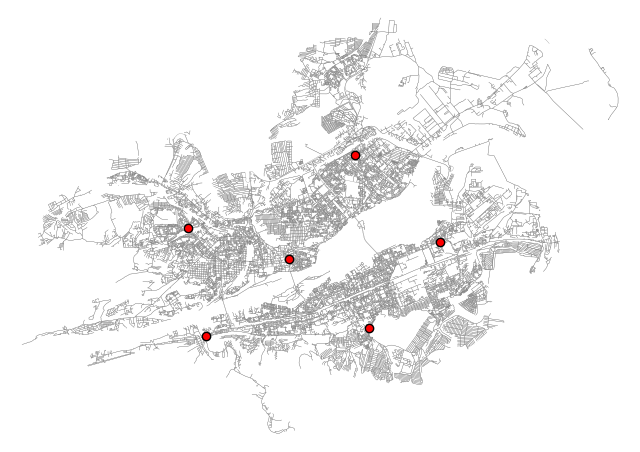

In [25]:
time_bound = 10

dynamic_nodes = {}
i = 0
for n in units[:6]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

times, _ = FirstArrivalUnitState()(env = G, points = dynamic_nodes)
print('Исходно')
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ',
      CoverIndexBuilding(buildings_set, ip_val = time_bound)(times),
      '%, tпр = ', ArrivalTime()(times),
      ArrivalTimeBuilding(buildings_set)(times))

# Карта
nodes_gdf = ox.graph_to_gdfs(G, edges=False)
fig,ax = ox.plot_graph(G, node_size=0, show=False, close=False, bgcolor='white', edge_color='grey', edge_linewidth=0.2)
nodes_gdf.loc[dynamic_nodes.keys()].plot(ax=ax, color='red', edgecolor='black')

#### Расчет при помощи ГА + Генезис

In [ ]:


time_bound = 10
target_ip  = 99
DISTANCE   = 250




# metric_opt = ArrivalTime()
metric_target = CoverIndexBuilding(buildings_set, ip_val = time_bound)

# Функция оптимизации k узлов методом hillclimber
# bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState())
bnhc = BestNodeHillClimbing_maxMean_Metric(state_function=FirstArrivalUnitState(), metric_function=metric_target)
# bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTimeBuilding(buildings_set))
# bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=metric_target)

kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                    #    metric_function = ArrivalTime(),
                       metric_function = metric_target,
                       best_point_function=bnhc,
                       iterations=6,
                       iter_calc_end_function=iter_func,
                       stop_case_function = NSameStopCase(3),      # Условие остановки не менее N одинаковых метрик
                       )


gakopt = BestNodesGAKopt(state_function = FirstArrivalUnitState(),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodeInDistanceSelector(ox.projection.project_gdf(nodes_gdf), distance=DISTANCE),                    
                    # node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),                    
                    population_size = 30,
                    epochs = 2,
                    elite_size = 15,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 0,
                    mutation_rate = 0.75,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )


genesis = LSCPCommon(
                    mclp_function = gakopt,
                    # mclp_function = kopt,
                    # point_selector = RandomNodesSelector(),
                    point_selector = FarNodeSelector(FirstArrivalUnitState()),                    
                    # point_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),
                    metric_function = metric_target,                        
                    # stop_case_function = MoreEqualStopCase(90),     # stop_case_function,
                    stop_case_function = stop_case_function(target_ip = target_ip, ip_val=time_bound),     # stop_case_function,
                    start_names_index = 100,
                    names_pattern='псч {}',
                    after_mclp_function = mclp_end_function,
                    )

dynamic_nodes = {
    list(nodes_gdf.index)[1000]: 'псч 1',
    list(nodes_gdf.index)[2000]: 'псч 2',
    list(nodes_gdf.index)[3000]: 'псч 3',
    list(nodes_gdf.index)[4000]: 'псч 4',
    list(nodes_gdf.index)[5000]: 'псч 5',
    list(nodes_gdf.index)[6000]: 'псч 6',
    # list(nodes_gdf.index)[2000]: 'псч 2',
    # list(nodes_gdf.index)[2000]: 'псч 2',
}


mclp_history = []
history_name = 'genesis_history.csv'

# Собственно расчет
t = TimeCheckPoint()
print('До LSCP:', len(dynamic_nodes))
best_dynamic_nodes, best_metric = genesis(env = G,
                                dynamic_nodes = dynamic_nodes,
                                # static_nodes = existed_units_dict,                          
                                # area = points_mask,
                                )
print('После LSCP:', len(best_dynamic_nodes), t())

optimal_nodes, best_metric = drop_trash_points(G,
                                FirstArrivalUnitState(),
                                metric_target,
                                stop_case_function(target_ip = target_ip),
                                best_dynamic_nodes,
                                # static_nodes = existed_units_dict,   
                                )
print('После отброса:', len(optimal_nodes), t())


times, _ = FirstArrivalUnitState()(env = G, points = optimal_nodes)
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings_set, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings_set)(times))

#### Попытка улучшить полученное размещение

In [ ]:
time_bound = 10
target_ip  = 90





# metric_opt = ArrivalTime()
metric_target = CoverIndexBuilding(buildings_set, ip_val = time_bound)

# Функция оптимизации k узлов методом hillclimber
# bnhc = BestNodeHillClimbing_HD_Max_Mean(state_function=FirstArrivalUnitState())
bnhc = BestNodeHillClimbing_maxMean_Metric(state_function=FirstArrivalUnitState(), metric_function=metric_target)
# bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=ArrivalTimeBuilding(buildings_set))
# bnhc = BestNodeHillClimbing(state_function=FirstArrivalUnitState(), metric_function=metric_target)

kopt = BestNodesKoptG(state_function=FirstArrivalUnitState(),
                       metric_function = metric_target,
                       best_point_function=bnhc,
                       iterations=3,
                       iter_calc_end_function=iter_func,
                       )


gakopt = BestNodesGAKopt(state_function = FirstArrivalUnitState(),
                    # metric_function = ArrivalTime(),            # Оптимизируем среднее время прибытия в любой узел
                    metric_function = metric_target,                        # Оптимизируем ИПЗ-10
                    kopt_function = kopt,
                    node_selector = RandomNodesSelector(),
                    # node_selector = GenesisNodeSelector(FirstArrivalUnitState(), metric_target),                    
                    population_size = 60,
                    epochs = 20,
                    elite_size = 15,
                    epoch_end_function = epoch_end_function,
                    mutation_max_count = 2,
                    mutation_rate = 1,
                    stop_case_function = NSameStopCase(15)      # Условие остановки не менее N одинаковых метрик
                    )


# genesis = LSCPCommon(
#                     mclp_function = gakopt,
#                     # mclp_function = kopt,
#                     # point_selector = RandomNodesSelector(),
#                     point_selector = FarNodeSelector(FirstArrivalUnitState()),                    
#                     # point_selector = GenesisNodeSelector(FirstArrivalUnitState(delay=0), metric_target),
#                     metric_function = metric_target,                        
#                     # stop_case_function = MoreEqualStopCase(90),     # stop_case_function,
#                     stop_case_function = stop_case_function(target_ip = target_ip, ip_val=time_bound),     # stop_case_function,
#                     start_names_index = 100,
#                     names_pattern='псч {}',
#                     after_mclp_function = mclp_end_function,
#                     )

dynamic_nodes = {}
i = 0
for n in units[:3]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

times, _ = FirstArrivalUnitState()(env = G, points = dynamic_nodes)
print('Исходно')
print('Новых ПСЧ:', len(dynamic_nodes), 'Всего ПСЧ:', len(units))
print(f'ИП-{time_bound} = ', CoverIndexBuilding(buildings_set, ip_val = time_bound)(times), '%, tпр = ', ArrivalTime()(times), ArrivalTimeBuilding(buildings_set)(times))



t = TimeCheckPoint()
# Собственно расчет
print('До LSCP:', len(dynamic_nodes))
best_dynamic_nodes, best_metric = gakopt(env = G,
                                dynamic_nodes = dynamic_nodes,
                                # static_nodes = existed_units_dict,                          
                                # area = points_mask,
                                )
print('После LSCP:', len(best_dynamic_nodes), t())

optimal_nodes, best_metric = drop_trash_points(G,
                                FirstArrivalUnitState(),
                                metric_target,
                                stop_case_function(target_ip = target_ip),
                                best_dynamic_nodes,
                                # static_nodes = existed_units_dict,   
                                )
print('После отброса:', len(optimal_nodes), t())

# Проверка объединения наборов данных

In [ ]:
dynamic_nodes = {}
i = 0
for n in units[:5]:
    dynamic_nodes[n] = f'pre {i}'
    i+=1

times, nearest = FirstArrivalUnitState()(env = G, points = dynamic_nodes)

In [ ]:
print(len(times), len(nearest))
nearest2 = nearest[nearest == 'pre 0']
times2 = times.loc[nearest2.keys()]
print(len(times2), len(nearest2))

In [ ]:
len(buildings)

In [ ]:
merged_df = pd.merge(buildings,
                    times2,
                    how         = 'left',
                    left_on     = 'node',
                    right_index = True)
print('left', len(merged_df))

merged_df = pd.merge(buildings,
                    times2,
                    how         = 'right',
                    left_on     = 'node',
                    right_index = True)
print('right', len(merged_df))

merged_df = pd.merge(buildings,
                    times2,
                    how         = 'outer',
                    left_on     = 'node',
                    right_index = True)
print('outer', len(merged_df))

merged_df = pd.merge(buildings,
                    times2,
                    how         = 'inner',
                    left_on     = 'node',
                    right_index = True)
print('inner', len(merged_df))


In [ ]:
buildings_s = buildings.query(f'node in @times2.keys()')
print('Зданий', len(buildings_s), 'Времен', len(times2))

merged_df = pd.merge(buildings_s,
                    times,
                    how         = 'left',
                    left_on     = 'node',
                    right_index = True)

print('left', len(merged_df))

In [ ]:
merged_df